In [1]:
import pandas as pd
import numpy   as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score



In [2]:
df = pd.read_csv('StudentsPerformance.csv')
print("Dataset ka shape (rows, columns):")
print(df.shape)
print("\nshow first 5 rows:")
print(df.head())
print("\nbasic info of each column:")
print(df.info())
print("\nNumerical summary (min, max, average):")
print(df.describe())

Dataset ka shape (rows, columns):
(1000, 8)

show first 5 rows:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

basic info of each column:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data 

In [3]:
print("Check is their any null value ?")
print(df.isnull().sum())
print("\nColumns:", df.columns.tolist())

Check is their any null value ?
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


In [4]:
#text data ko numerical data me convert karna
le = LabelEncoder()
text_columns = ['gender', 
                'race/ethnicity', 
                'parental level of education',
                'lunch', 
                'test preparation course']
for col in text_columns:
    df[col] = le.fit_transform(df[col])
    print("\nData after converting text :")
print(df.head())


Data after converting text :

Data after converting text :

Data after converting text :

Data after converting text :

Data after converting text :
   gender  race/ethnicity  parental level of education  lunch  \
0       0               1                            1      1   
1       0               2                            4      1   
2       0               1                            3      1   
3       1               0                            0      0   
4       1               2                            4      1   

   test preparation course  math score  reading score  writing score  
0                        1          72             72             74  
1                        0          69             90             88  
2                        1          90             95             93  
3                        1          47             57             44  
4                        1          76             78             75  


In [5]:
# x and y ko define karna , x jo hm model ko denge aur y jo hm predict karna chahte hain
X = df[['gender', 
        'race/ethnicity', 
        'parental level of education',
        'lunch', 
        'test preparation course',
        'reading score',
        'writing score']]
y = df['math score']
print("Input features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Input features (X) shape: (1000, 7)
Target (y) shape: (1000,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,           
    y,           
    test_size=0.2,   # 20% data testing ke liye
    random_state=42  # Taaki har baar same split ho
)
print(f"Training data: {X_train.shape[0]} students")

print(f"Testing data: {X_test.shape[0]} students")


Training data: 800 students
Testing data: 200 students


In [7]:
model = RandomForestRegressor(
    n_estimators=100,  # 100 decision trees banao
    random_state=42    
)
print("Start training the model")
model.fit(X_train, y_train)
print("Model training completed")

Start training the model
Model training completed


In [8]:
#predict krna aur model check krna ki kitna accurate hai
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nMODEL RESULTS:")
print(f"Mean Absolute Error: {mae:.2f} marks")
print(f"R2 Score (Accuracy): {r2:.2f}")
print(f"Model Accuracy: {r2*100:.1f}%")


MODEL RESULTS:
Mean Absolute Error: 4.70 marks
R2 Score (Accuracy): 0.85
Model Accuracy: 84.9%


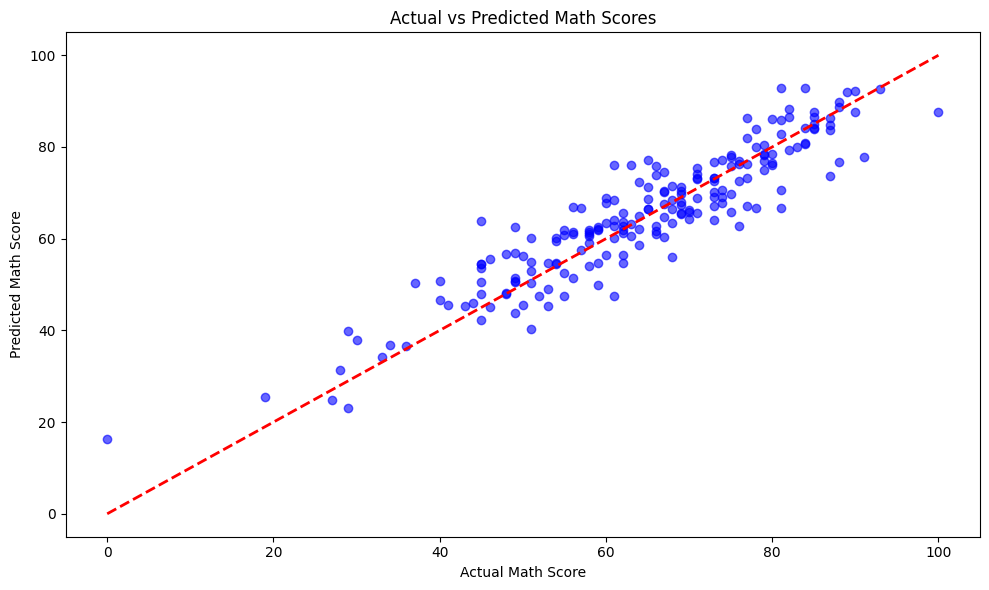

Graph 1 is saved as 'actual_vs_predicted.png' 


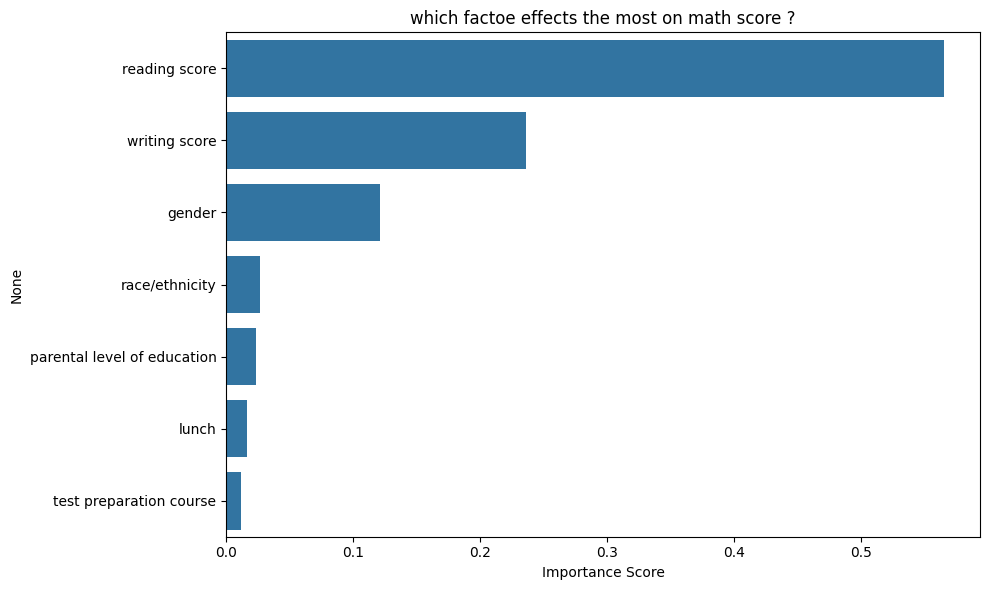

Graph 2 is saved as 'feature_importance.png' 


In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([0, 100], [0, 100], 'r--', linewidth=2)
plt.xlabel('Actual Math Score')
plt.ylabel('Predicted Math Score')
plt.title('Actual vs Predicted Math Scores')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')  # Save karo
plt.show()
print("Graph 1 is saved as 'actual_vs_predicted.png' ")

feature_importance = pd.Series(
    model.feature_importances_,  
    index=X.columns              # Feature ka naam
).sort_values(ascending=False)   
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index)

plt.title('which factoe effects the most on math score ?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()
print("Graph 2 is saved as 'feature_importance.png' ")


In [10]:
#predict on new student data

new_student = pd.DataFrame({
    'gender': [0],                          
    'race/ethnicity': [2],                  
    'parental level of education': [3],     
    'lunch': [1],                           
    'test preparation course': [1],        
    'reading score': [75],                  
    'writing score': [70]         
})          

predicted_score = model.predict(new_student)
print(f"\npredicted score of new student: {predicted_score[0]:.1f}")


predicted score of new student: 63.7
